In [1]:
# 1. Standard library imports
import logging
import math
import os
import re
import json
import time
from typing import Dict, List, Optional, Tuple
from pathlib import Path

# 2. Related third-party imports
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint
from tqdm import tqdm
import tiktoken
from glob import glob
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, LinearLR, SequentialLR

# Add at the top after imports:
try:
    from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo
    NVML_AVAILABLE = True
    nvmlInit()
except ImportError:
    NVML_AVAILABLE = False


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
def show_vram_usage():
    if not NVML_AVAILABLE or not torch.cuda.is_available():
        return "NVML not available or no CUDA device"
    try:
        handle = nvmlDeviceGetHandleByIndex(0)
        info = nvmlDeviceGetMemoryInfo(handle)
        return f"Used: {info.used // (1024 ** 2)} MB, Free: {info.free // (1024 ** 2)} MB, Total: {info.total // (1024 ** 2)} MB"
    except Exception as e:
        return f"NVML error: {e}"

In [3]:
print(show_vram_usage())

Used: 636 MB, Free: 11651 MB, Total: 12288 MB


In [4]:
# src/gemma3.py
"""
Gemma-3 style Transformer model (reference implementation)

This module provides:
 - compute_rope_params / apply_rope : rotary positional embedding utilities
 - RMSNorm : normalization used by Gemma/LLaMA (recommended over LayerNorm)
 - GroupedQueryAttention : grouped-key/value attention (Gemma-style)
 - FeedForward : gated FFN (Gemma-style SwiGLU-like)
 - TransformerBlock : single block combining attention + FFN + RMS norms
 - Gemma3Model : full autoregressive model with precomputed RoPE caches

Design notes:
 - Many weights are instantiated with `dtype` from the model config so model
   initialization can allocate parameters in lower precision (e.g. bfloat16).
 - RoPE caches (cos/sin) are stored in float32 for numerical stability and are
   moved to the device at forward time.
 - Masking expected is boolean with True == masked positions (compatible with
   `masked_fill(mask, -inf)`).
"""

from typing import Tuple, Optional, Dict, Any
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------
# RoPE utilities
# ----------------------------
def compute_rope_params(head_dim: int, theta_base: int = 10_000, context_length: int = 4096, dtype=torch.float32) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Precompute RoPE cosine and sine caches.

    Parameters
    ----------
    head_dim : int
        Dimension of a single attention head (must be even).
    theta_base : int
        Rotary base (10_000 in literature). Larger base compresses freq spacing.
    context_length : int
        Maximum context length for precomputation (T).
    dtype : torch.dtype
        dtype for the precomputed caches (float32 recommended).

    Returns
    -------
    cos, sin : torch.Tensor
        Two tensors of shape (context_length, head_dim) in `dtype`.
    """
    assert head_dim % 2 == 0, "head_dim must be even for RoPE"
    half = head_dim // 2
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, half, dtype=dtype) / half))
    positions = torch.arange(context_length, dtype=dtype)
    angles = positions[:, None] * inv_freq[None, :]  # (T, half)
    angles = torch.cat([angles, angles], dim=-1)     # (T, head_dim)
    return torch.cos(angles), torch.sin(angles)


def apply_rope(x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
    """
    Apply RoPE rotation to Q or K tensor.

    Parameters
    ----------
    x : Tensor
        shape (B, heads, T, head_dim)
    cos, sin : Tensor
        RoPE caches of shape (T_cache, head_dim) (float32 recommended)

    Returns
    -------
    Tensor
        x after applying rotary transform (same dtype as input `x`).
    """
    B, H, T, D = x.shape
    assert D % 2 == 0, "head_dim must be even"
    x1 = x[..., : D // 2]
    x2 = x[..., D // 2 :]
    # move cos/sin to correct device and slice to seq length
    cos = cos[:T, :].to(x.device).unsqueeze(0).unsqueeze(0)   # (1,1,T,D)
    sin = sin[:T, :].to(x.device).unsqueeze(0).unsqueeze(0)
    # rotate halves
    rotated = torch.cat([-x2, x1], dim=-1)
    x_rot = x * cos + rotated * sin
    return x_rot.to(dtype=x.dtype)


# ----------------------------
# RMSNorm
# ----------------------------
class RMSNorm(nn.Module):
    """
    Root-Mean-Square Layer Normalization (used in Gemma, LLaMA variants).

    This implementation follows the Gemma convention where the learned scale
    parameter `g` is stored zero-centered and applied as `out = norm * (1 + g)`.
    """
    def __init__(self, dim: int, eps: float = 1e-6, bias: bool = False):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.zeros(dim))
        self.shift = nn.Parameter(torch.zeros(dim)) if bias else None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # compute RMS in float32 for numeric stability
        dtype_in = x.dtype
        x_f = x.float()
        var = x_f.pow(2).mean(dim=-1, keepdim=True)
        x_norm = x_f * torch.rsqrt(var + self.eps)
        out = x_norm * (1.0 + self.scale.float())
        if self.shift is not None:
            out = out + self.shift.float()
        return out.to(dtype_in)


# ----------------------------
# GroupedQueryAttention
# ----------------------------
class GroupedQueryAttention(nn.Module):
    """
    Grouped-query attention (Gemma-style): fewer keys/values than queries,
    with group expansion (repeat_interleave) for K/V.

    Parameters
    ----------
    d_in : int
        Input embedding dimension.
    num_heads : int
        Number of attention heads.
    num_kv_groups : int
        How many distinct key/value groups (<= num_heads).
    head_dim : Optional[int]
        Head dimension (if None then d_in // num_heads).
    qk_norm : bool
        If True apply RMSNorm to queries and keys (optional).
    query_pre_attn_scalar : Optional[float]
        If provided, uses this for scaling (like query_pre_attn_scalar ** -0.5).
    dtype : Optional[torch.dtype]
        Parameter dtype for linear layers (if supported).
    """
    def __init__(self, d_in: int, num_heads: int, num_kv_groups: int, head_dim: Optional[int] = None, qk_norm: bool = False, query_pre_attn_scalar: Optional[float] = None, dtype=None):
        super().__init__()
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"
        self.num_heads = num_heads
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups

        if head_dim is None:
            assert d_in % num_heads == 0
            head_dim = d_in // num_heads
        self.head_dim = head_dim
        self.d_out = num_heads * head_dim

        linear_kwargs = {"bias": False}
        if dtype is not None:
            linear_kwargs["dtype"] = dtype

        self.W_query = nn.Linear(d_in, self.d_out, **linear_kwargs)
        self.W_key = nn.Linear(d_in, num_kv_groups * head_dim, **linear_kwargs)
        self.W_value = nn.Linear(d_in, num_kv_groups * head_dim, **linear_kwargs)
        self.out_proj = nn.Linear(self.d_out, d_in, bias=False, **({"dtype": dtype} if dtype is not None else {}))

        self.q_norm = RMSNorm(head_dim, eps=1e-6) if qk_norm else None
        self.k_norm = RMSNorm(head_dim, eps=1e-6) if qk_norm else None

        if query_pre_attn_scalar is not None:
            self.scaling = (query_pre_attn_scalar) ** -0.5
        else:
            self.scaling = (head_dim) ** -0.5

    def forward(self, x: torch.Tensor, mask: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
        """
        x shape: (B, T, d_in)
        mask shape: (T, T) boolean mask with True for masked positions
        cos/sin: rope caches (T_cache, head_dim)
        """
        b, num_tokens, _ = x.shape
        queries = self.W_query(x)   # (b, T, num_heads * head_dim)
        keys = self.W_key(x)        # (b, T, num_kv_groups * head_dim)
        values = self.W_value(x)    # (b, T, num_kv_groups * head_dim)

        # reshape to (b, heads, T, head_dim)
        q = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        k = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)
        v = values.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)

        if self.q_norm:
            q = self.q_norm(q)
        if self.k_norm:
            k = self.k_norm(k)

        # apply RoPE to q,k (cos/sin are float32 caches)
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        # expand keys/values across heads
        k = k.repeat_interleave(self.group_size, dim=1)    # (b, heads, T, head_dim)
        v = v.repeat_interleave(self.group_size, dim=1)

        # scale queries then compute attention
        q = q * self.scaling
        # attn scores: (b, heads, T, T)
        attn_scores = q @ k.transpose(-2, -1)
        # mask: broadcastable (T,T) -> (b, heads, T, T)
        attn_scores = attn_scores.masked_fill(mask, float("-inf"))
        attn_weights = torch.softmax(attn_scores, dim=-1)

        context = (attn_weights @ v).transpose(1, 2).reshape(b, num_tokens, self.d_out)  # (b, T, d_out)
        return self.out_proj(context)


# ----------------------------
# FeedForward (Gemma-style, gated)
# ----------------------------
class FeedForward(nn.Module):
    """
    Gemma-style feed-forward network: two parallel projections then gated GELU / multiply.
    Uses fc1 (gate), fc2 (up), fc3 (down).
    """
    def __init__(self, cfg: Dict[str, Any]):
        super().__init__()
        self.model_dtype = cfg.get("dtype", torch.float32)
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=self.model_dtype, bias=False)
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=self.model_dtype, bias=False)
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], dtype=self.model_dtype, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.fc1(x)
        x2 = self.fc2(x)
        # Gemma uses GELU with "tanh" approximate sometimes
        out = F.gelu(x1, approximate="tanh") * x2
        return self.fc3(out)


# ----------------------------
# TransformerBlock
# ----------------------------
class TransformerBlock(nn.Module):
    """
    Single Gemma transformer block.

    This block operates in pre-norm style:
      x -> input_layernorm -> attention -> post_attention_norm -> residual add ->
           pre_feedforward_norm -> ffn -> post_feedforward_norm -> residual add

    Attn choices determined by `attn_type` (e.g. "global" or "sliding_attention").
    """
    def __init__(self, cfg: Dict[str, Any], attn_type: str, use_checkpoint: bool = False):
        super().__init__()
        self.model_dtype = cfg.get("dtype", torch.float32)
        self.attn_type = attn_type
        self.use_checkpoint = use_checkpoint
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            num_kv_groups=cfg["n_kv_groups"],
            head_dim=cfg.get("head_dim", None),
            qk_norm=cfg.get("qk_norm", False),
            query_pre_attn_scalar=cfg.get("query_pre_attn_scalar", None),
            dtype=self.model_dtype,
        )
        self.ff = FeedForward(cfg)
        self.input_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.post_attention_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.pre_feedforward_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.post_feedforward_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)

    def forward(self, x, mask_global, mask_local, cos_global, sin_global, cos_local, sin_local):
        shortcut = x
        x = self.input_layernorm(x)

        if self.attn_type == "sliding_attention":
            attn_mask = mask_local
            cos = cos_local
            sin = sin_local
        else:
            attn_mask = mask_global
            cos = cos_global
            sin = sin_global

        if self.use_checkpoint and self.training:
            # checkpoint the attention call (pass all arguments required)
            x_attn = torch.utils.checkpoint.checkpoint(self.att, x, attn_mask, cos, sin)
        else:
            x_attn = self.att(x, attn_mask, cos, sin)
        x_attn = self.post_attention_layernorm(x_attn)
        x = shortcut + x_attn

        shortcut = x
        x_ffn_in = self.pre_feedforward_layernorm(x)
        if self.use_checkpoint and self.training:
            x_ffn = torch.utils.checkpoint.checkpoint(self.ff, x_ffn_in)
        else:
            x_ffn = self.ff(x_ffn_in)
        x_ffn = self.post_feedforward_layernorm(x_ffn)
        x = shortcut + x_ffn
        return x


# ----------------------------
# Gemma3Model (full model)
# ----------------------------
class Gemma3Model(nn.Module):
    """
    Gemma-3 style autoregressive Transformer.

    Parameters
    ----------
    cfg : dict
        Required keys:
            - vocab_size, emb_dim, head_dim, n_heads, n_kv_groups,
            - hidden_dim, n_layers, layer_types (list of length n_layers),
            - context_length, rope_base, rope_local_base, sliding_window
            - dtype (torch.dtype)  <-- sets param dtype where supported
    use_checkpoint : bool
        If True, enable activation checkpointing inside each TransformerBlock
        for memory savings (recompute on backward).

    Notes
    -----
    - Token embedding uses scale sqrt(emb_dim) (as in many transformer implementations).
    - Final normalization is RMSNorm and final head projects to vocab.
    - RoPE caches (cos/sin) are precomputed as float32 and stored as buffers.
    """
    def __init__(self, cfg: Dict[str, Any], use_checkpoint: bool = False):
        super().__init__()
        assert cfg.get("layer_types") is not None and len(cfg["layer_types"]) == cfg["n_layers"]
        self.model_dtype = cfg.get("dtype", torch.float32)
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=self.model_dtype)
        # build blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(cfg, attn_type=cfg["layer_types"][i], use_checkpoint=use_checkpoint)
            for i in range(cfg["n_layers"])
        ])
        self.final_norm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=self.model_dtype)

        # Precompute RoPE caches (float32) and register as non-persistent buffers
        cos_local, sin_local = compute_rope_params(cfg["head_dim"], theta_base=cfg["rope_local_base"], context_length=cfg["context_length"], dtype=torch.float32)
        cos_global, sin_global = compute_rope_params(cfg["head_dim"], theta_base=cfg["rope_base"], context_length=cfg["context_length"], dtype=torch.float32)
        # Do not persist caches in checkpoint to reduce checkpoint size
        self.register_buffer("cos_local", cos_local, persistent=False)
        self.register_buffer("sin_local", sin_local, persistent=False)
        self.register_buffer("cos_global", cos_global, persistent=False)
        self.register_buffer("sin_global", sin_global, persistent=False)

        # initialize parameters
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if getattr(module, "bias", None) is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def _create_masks(self, seq_len: int, device: torch.device):
        """
        Create two boolean masks:
         - mask_global: upper triangular (j>i) -> future masked
         - mask_local: mask_global OR far_past (sliding_window)
        Both masks are dtype bool and shape (T, T) for broadcast into attention tensors.
        """
        ones = torch.ones((seq_len, seq_len), dtype=torch.bool, device=device)
        mask_global = torch.triu(ones, diagonal=1)  # True for positions to mask
        far_past = torch.triu(ones, diagonal=self.cfg["sliding_window"]).T
        mask_local = mask_global | far_past
        return mask_global, mask_local

    def forward(self, input_ids: torch.LongTensor, targets: Optional[torch.LongTensor] = None):
        """
        Forward pass.

        Parameters
        ----------
        input_ids : (B, T) long tensor
        targets : (B, T) long tensor, optional

        Returns
        -------
        logits : (B, T, V)
        loss : scalar tensor if targets is provided (computed in float32)
        """
        b, seq_len = input_ids.shape
        device = input_ids.device
        # token embedding and scale
        x = self.tok_emb(input_ids) * (self.cfg["emb_dim"] ** 0.5)
        mask_global, mask_local = self._create_masks(seq_len, device)

        # Iterate blocks: pass precomputed rope caches (float32); block moves them to device as needed
        for block in self.blocks:
            x = block(x, mask_global, mask_local, self.cos_global, self.sin_global, self.cos_local, self.sin_local)

        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg.get("dtype", x.dtype)))  # cast to head dtype if configured

        loss = None
        if targets is not None:
            # compute loss in float32 for stability
            logits_f32 = logits.to(torch.float32)
            loss = F.cross_entropy(logits_f32.reshape(-1, logits_f32.size(-1)), targets.reshape(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, input_tokens: torch.LongTensor, max_new_tokens: int, temperature: float = 1.0, top_k: Optional[int] = None) -> torch.LongTensor:
        """
        Simple autoregressive sampling (batched).

        Parameters
        ----------
        input_tokens : (B, T) long tensor of initial token ids
        max_new_tokens : int
        temperature : float
        top_k : Optional[int]

        Returns
        -------
        Tensor (B, T + max_new_tokens)
        """
        for _ in range(max_new_tokens):
            ctx_len = self.cfg["context_length"]
            input_tokens_cond = input_tokens if input_tokens.size(1) <= ctx_len else input_tokens[:, -ctx_len:]
            logits, _ = self(input_tokens_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")
            probs = F.softmax(logits, dim=-1)
            input_tokens_next = torch.multinomial(probs, num_samples=1)
            input_tokens = torch.cat((input_tokens, input_tokens_next), dim=1)
        return input_tokens


In [5]:
print(show_vram_usage())

Used: 636 MB, Free: 11651 MB, Total: 12288 MB


In [6]:
print(show_vram_usage())

Used: 636 MB, Free: 11651 MB, Total: 12288 MB


In [7]:
# --- NEW: parquet -> tokens -> (x,y) streaming dataset -----------------
import os, random, itertools, logging
from collections import deque
from typing import Iterable, List, Optional

import pyarrow.dataset as ds
import pyarrow as pa
import tiktoken
import torch
from torch.utils.data import IterableDataset, get_worker_info

logger = logging.getLogger(__name__)

# you already have these helpers; reusing names so you can delete duplicates if desired
def choose_string_column(dataset: ds.dataset) -> str:
    schema = dataset.schema
    str_columns = [f.name for f in schema if pa.types.is_string(f.type)]
    for candidate in ("text","content","body"):
        if candidate in str_columns:
            return candidate
    if not str_columns:
        raise RuntimeError("No string column in parquet schema(s)")
    return str_columns[0]

def is_english_text(text: str, mode: str = "accuracy", ascii_threshold: float = 0.5) -> bool:
    # same logic you already use (paste your implementation here)
    import langid
    if mode == "skip": return True
    if not text: return False
    def ascii_fraction(s): 
        return 0.0 if not s else sum(1 for c in s if ord(c) < 128)/len(s)
    if mode in ("ascii","fast"): return ascii_fraction(text) >= ascii_threshold
    try:
        lang, _ = langid.classify(text)
        if lang == "en": return True
    except Exception: pass
    return ascii_fraction(text) >= ascii_threshold

def _get_eos_token_id(enc: "tiktoken.Encoding", model_hint: str = "gpt2") -> Optional[int]:
    try:
        ids = enc.encode("", allowed_special={"<|endoftext|>"})
        if ids: return int(ids[0])
    except Exception: pass
    try:
        ids = enc.encode("")
        if ids: return int(ids[0])
    except Exception: pass
    if model_hint.lower().startswith("gpt2"):
        return 50256
    return None

class ParquetCausalIterable(IterableDataset):
    """
    Streams parquet rows -> filter -> tokenize -> rolling buffer -> emits (x,y)
    pairs of length `block_size` with stride `stride`.

    Notes
    -----
    - Designed for DataLoader(num_workers>0, prefetch_factor>1, persistent_workers=True).
    - Each worker scans its own shard of files (round-robin).
    - Tokenizer/langid are created inside worker processes.
    - EOS is appended after each *row*; crossing rows is allowed (continuous stream).
    """
    def __init__(
        self,
        files: Optional[List[str]] = None,
        input_dir: Optional[str] = None,
        pattern: str = "*.parquet",
        text_col: Optional[str] = None,
        batch_rows: int = 4096,
        target_chunk_bytes: int = 100_000_000,
        tokenizer_model: str = "gpt2",
        add_eos: bool = True,
        block_size: int = 1024,
        stride: Optional[int] = None,
        lang_mode: str = "skip",
        ascii_threshold: float = 0.5,
        shuffle_files: bool = True,
        seed: int = 1337,
    ):
        self._all_files = files
        self.input_dir = input_dir
        self.pattern = pattern
        self.text_col = text_col
        self.batch_rows = int(batch_rows)
        self.target_chunk_bytes = int(target_chunk_bytes)
        self.tokenizer_model = tokenizer_model
        self.add_eos = add_eos
        self.block_size = int(block_size)
        self.stride = int(stride if stride is not None else block_size)  # no overlap by default
        self.lang_mode = lang_mode
        self.ascii_threshold = ascii_threshold
        self.shuffle_files = shuffle_files
        self.seed = int(seed)

    def _files(self) -> List[str]:
        if self._all_files is not None:
            return list(self._all_files)
        if not self.input_dir:
            raise ValueError("Provide either `files` or `input_dir`.")
        p = Path(self.input_dir)
        if not p.exists():
            raise FileNotFoundError(self.input_dir)
        return sorted(str(x) for x in p.glob(self.pattern))

    def _shard_for_worker(self, files: List[str]) -> List[str]:
        info = get_worker_info()
        if info is None:
            shard = files
            rng = random.Random(self.seed)
        else:
            shard = files[info.id::info.num_workers]  # round-robin
            rng = random.Random(self.seed + info.id)
        if self.shuffle_files:
            rng.shuffle(shard)
        return shard

    def _yield_sequences(self, token_buffer: List[int]) -> Iterable[torch.Tensor]:
        """
        Given a growing token buffer, yield fixed-length (block_size+1) sequences
        advancing by self.stride. Uses an index pointer to avoid O(N) pops.
        """
        i = 0
        bs1 = self.block_size + 1
        # periodically compact buffer to control memory
        COMPACT_EVERY = max(8 * self.block_size, 32768)
        while i + bs1 <= len(token_buffer):
            seq = token_buffer[i : i + bs1]
            yield torch.tensor(seq, dtype=torch.long)  # CPU tensor; DataLoader can pin & move
            i += self.stride
            if i > COMPACT_EVERY:
                # drop consumed prefix
                del token_buffer[:i]
                i = 0

        # keep only the tail we still need for future continuation
        if i > 0:
            del token_buffer[:i]

    def __iter__(self):
        # Per-worker state
        enc = tiktoken.get_encoding(self.tokenizer_model)
        eos_id = _get_eos_token_id(enc, self.tokenizer_model) if self.add_eos else None

        files = self._shard_for_worker(self._files())
        if not files:
            return

        token_buffer: List[int] = []

        for file in files:
            dataset = ds.dataset([file], format="parquet")
            col = self.text_col or choose_string_column(dataset)
            scanner = dataset.scanner(batch_size=self.batch_rows)

            for rb in scanner.to_batches():
                arr = rb[col]
                # Accumulate tokens for this batch of rows
                for raw in arr.to_pylist():
                    if raw is None:
                        continue
                    text = str(raw).strip()
                    if not text:
                        continue
                    if not is_english_text(text, mode=self.lang_mode, ascii_threshold=self.ascii_threshold):
                        continue
                    try:
                        toks = enc.encode_ordinary(text)
                    except Exception:
                        toks = enc.encode(text)
                    if toks:
                        token_buffer.extend(toks)
                        if eos_id is not None:
                            token_buffer.append(eos_id)

                # As tokens accumulate, yield sequences
                for seq in self._yield_sequences(token_buffer):
                    # Each item from this IterableDataset is one 1D seq of length block_size+1
                    yield seq

            # small compaction at file boundary
            # (keep at most block_size tokens to continue across files)
            if len(token_buffer) > self.block_size:
                token_buffer[:] = token_buffer[-self.block_size:]

# --- NEW: simple collate that turns seq->(x,y) --------------------------
def shift_collate(batch: List[torch.Tensor]):
    """
    batch: list of tensors shape (block_size+1,)
    returns:
        X: (B, block_size)
        Y: (B, block_size)
    """
    seqs = torch.stack(batch, dim=0)  # (B, L+1)
    return seqs[:, :-1].contiguous(), seqs[:, 1:].contiguous()


GPT2 Training Sliding Window with Overlap

In [8]:
## -- Utility Functions ---------------------------------------------------
# -- Getting Size of Vocab Function ------------------------------------------
def get_vocab_size(encoding_name: str) -> int:
    """
    Return the vocabulary size for a given encoding in tiktoken.

    Args:
        encoding_name: Name of the encoding (e.g. "gpt2", "cl100k_base", etc.)

    Returns:
        The total number of tokens in that encoding’s vocabulary.
    """
    encoding = tiktoken.get_encoding(encoding_name)
    return encoding.n_vocab


# -- Estimate Loss -------------------------------------------------
@torch.no_grad()
def estimate_loss_from_loaders(
    model,
    train_loader,
    val_loader,
    device: str,
    autocast_dtype, 
    eval_iters: int,
    max_eval_iters: int = 50,
):
    """
    Evaluate model loss on a few batches from train/val loaders.

    - Adaptive eval_iters: fewer steps when eval_interval is short.
    - Temporarily disables checkpointing for faster forward pass.
    """
    model.eval()

    # disable gradient checkpointing if model supports it
    had_checkpoint_attr = hasattr(model, "gradient_checkpointing")
    if had_checkpoint_attr:
        old_checkpoint_state = model.gradient_checkpointing
        model.gradient_checkpointing = False

    # decide eval_iters adaptively
    eval_iters = min(max_eval_iters, eval_iters)

    totals, counts = {"train": 0.0, "val": 0}, {"train": 0, "val": 0}

    for name, loader in [("train", train_loader), ("val", val_loader)]:
        it = iter(loader)
        for _ in range(eval_iters):
            X, Y = next(it)
            X, Y = X.to(device, non_blocking=True), Y.to(device, non_blocking=True)
            with torch.autocast(device_type=device, dtype=autocast_dtype):
                _, loss = model(X, Y)
            totals[name] += loss.item()
            counts[name] += 1

    # restore checkpointing state if needed
    if had_checkpoint_attr:
        model.gradient_checkpointing = old_checkpoint_state

    model.train()
    return {k: totals[k] / counts[k] for k in totals}




# -- Checkpoint Saving -------------------------------------------------
def save_checkpoint(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    batches_seen: List[int],
    train_losses: List[float],
    val_losses: List[float],
    file_path: str,
    scaler: torch.cuda.amp.GradScaler = None, # Optional scaler argument
    warmup_scheduler: torch.optim.lr_scheduler.LRScheduler = None,  # Optional warmup argument
    plateau_scheduler: torch.optim.lr_scheduler.LRScheduler = None  # Optional plateau argument
) -> None:
    """ 
    Save model, optimizer, scaler (optional), and training history to disk for later resumption and plotting.

    Args:
        model (torch.nn.Module): Trained GPTLanguageModel.
        optimizer (torch.optim.Optimizer): Associated optimizer (e.g., AdamW).
        epoch (int): Current epoch or step number.
        loss (float): Latest loss value.
        batches_seen (List[int]): List of batch-indices at which evals were performed.
        train_losses (List[float]): Recorded training losses at each eval point.
        val_losses (List[float]): Recorded validation losses at each eval point.
        file_path (str): File path for checkpoint.
        scaler (torch.cuda.amp.GradScaler, optional): GradScaler for mixed precision training.

    Notes:
        - Saves a dict with keys:
          * 'epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'
          * 'history': contains 'batches_seen', 'train_losses', 'val_losses'
          * 'scaler_state_dict' (if scaler is provided)
        - Later, loading this checkpoint allows both exact model/optimizer restoration
          and re-plotting of the entire train/val loss curve.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'history': {
            'batches_seen': batches_seen,
            'train_losses': train_losses,
            'val_losses': val_losses,
        }
    }
    if scaler is not None:
        checkpoint['scaler_state_dict'] = scaler.state_dict()
    if warmup_scheduler is not None:
        checkpoint['warmup_state_dict'] = warmup_scheduler.state_dict()
    if plateau_scheduler is not None:
        checkpoint['plateau_scheduler_state_dict'] = plateau_scheduler.state_dict()
    torch.save(checkpoint, file_path)


def get_total_params_gpt2(model: torch.nn.Module) -> int:
    """
    Compute the total number of *unique* trainable parameters in a GPT-2 model,
    correctly accounting for weight tying between the input embeddings and the
    output language modeling head.

    GPT-2 ties the weights of its input embedding matrix and the output projection
    (lm_head).  Although these weights appear twice in the model's parameter list,
    they should only be counted once when reporting the total number of parameters.

    Args:
        model (torch.nn.Module):
            A GPT-2 model instance (e.g. from Hugging Face's transformers library),
            which must have an attribute `lm_head` representing the output projection
            layer.

    Returns:
        int: The total number of unique parameters in the GPT-2 model, with the
             duplicated `lm_head` parameters subtracted out.
    """
    # 1) Count every parameter in the model (embeddings, transformer blocks, lm_head, etc.)
    total_params = sum(p.numel() for p in model.parameters())

    # 2) Count only the parameters in the output head (lm_head).
    #    These share weights with the input embedding matrix under weight-tying.
    lm_head_params = sum(p.numel() for p in model.lm_head.parameters())

    # 3) Subtract the lm_head params once so they're not double-counted,
    #    yielding the true GPT-2 parameter count.
    unique_gpt2_params = total_params - lm_head_params

    return unique_gpt2_params

def get_total_model_size_mb(model: torch.nn.Module) -> int:
    total_params = sum(p.numel() for p in model.parameters())
    total_size_bytes = total_params * 4 #A
    total_size_mb = total_size_bytes / (1024 * 1024) #B
    return total_size_mb

In [9]:
def get_total_params_model(model: torch.nn.Module) -> int:
    model_to_check = model.module if hasattr(model, "module") else model
    total_params = sum(p.numel() for p in model_to_check.parameters())
    # Gemma uses out_head name; subtract if weight-tying present
    if hasattr(model_to_check, "lm_head"):
        lm_params = sum(p.numel() for p in model_to_check.lm_head.parameters())
    elif hasattr(model_to_check, "out_head"):
        lm_params = sum(p.numel() for p in model_to_check.out_head.parameters())
    else:
        lm_params = 0
    return total_params - lm_params

In [10]:

"""
Streaming pre-training loop for a GPT-style autoregressive language model.

High-level flow
---------------
1. Data are streamed from Parquet shards → tokenized on-the-fly → overlapping
   sliding windows (stride < block_size) to maximize data efficiency.
2. Mixed-precision (`bfloat16`) and gradient accumulation are used to fit large
   models and long sequences on modest GPUs.
3. Training is measured in **effective steps** (optimizer updates) rather than
   micro-batches for intuitive scheduling of evals, checkpoints, LR warm-up, etc.
4. Early stopping, LR-scheduling on plateau, NaN guards, and deterministic
   checkpointing are all built-in.

Key symbols
-----------
effective_step       number of times the optimizer has actually stepped
batches_processed    raw mini-batches consumed (micro-steps)
grads_accum_steps    how many micro-batches are averaged into one effective step
eval_interval        effective steps between validation runs
save_interval        effective steps between checkpoints
warmup_steps         effective steps over which LR rises from 0 → base_lr

Implementation notes
--------------------
- optimizer.zero_grad is called once per effective step only.
- Loss is **mean-reduced** across the accumulation window via
  `loss = loss / grads_accum_steps`.
- tqdm bar updates on every effective step; logs and filenames use the same unit.
- ReduceLROnPlateau is stepped after **every** validation (not only when the
  interval doubles) to guarantee LR decay when loss plateaus.
- Warm-up uses effective_step, so `warmup_steps=2000` means 2000 optimizer updates.
"""

# -- Logging Configuration ----------------------------------------------
run_id = int(time.time())

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S", 
    encoding='utf-8'
)
logger = logging.getLogger(__name__)

# Ensure logs directory exists
LOG_DIR = os.path.join("logs")
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)

# Create file handler
log_file = os.path.join(LOG_DIR, f"train_{run_id}.log")
file_handler = logging.FileHandler(log_file, mode='w', encoding='utf-8')
file_handler.setLevel(logging.DEBUG)

# Optional: use same format as console
formatter = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", "%H:%M:%S")
file_handler.setFormatter(formatter)

# Add handler to logger
logger.addHandler(file_handler)
logger.info(f"Logging to file: {log_file}")


device = 'cuda' if torch.cuda.is_available() else 'cpu'
logger.info(f"Using device: {device}")

seed = 1337
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if device == 'cuda':
    torch.cuda.manual_seed_all(seed)
    torch.backends.cuda.matmul.allow_tf32 = True  # ~20% speedup on Ampere+
    torch.backends.cudnn.allow_tf32 = True

# -------------------------
# GradScaler setup
# -------------------------
# More robust mixed precision setup
if device == "cuda": 
    autocast_dtype = torch.bfloat16  # Better than float16 for training
    use_scaler = False  # bfloat16 doesn't need gradient scaling
else:
    autocast_dtype = torch.float16
    use_scaler = True

scaler = GradScaler(enabled=use_scaler) if device == "cuda" else None

# -- Load Tokenizer -----------------------------------------------------
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)
vocab_size = get_vocab_size(encoding_name) 
while(vocab_size%64 != 0): vocab_size+=1 # override with larger value that is divisable by 64 
logger.info(f"Vocab size: {vocab_size}")

# -- Model Configuration ------------------------------------------------
torch.manual_seed(1337)
block_size = 1024
n_embd = 1024 # 768 1024 1280
n_head = 16 # 12 16 20
n_layer = 24 # 12 24 36
dropout = 0.1
batch_size = 1



cfg = {
    "vocab_size": vocab_size,
    "emb_dim": n_embd,
    "head_dim": n_embd // n_head,
    "n_heads": n_head,
    "n_kv_groups": 1,             # Gemma often uses grouped KV; tune as needed
    "hidden_dim": 4 * n_embd,     # ff width
    "n_layers": n_layer,
    "layer_types": ["global"] * n_layer,   # or mix "sliding_attention" per layer if desired
    "context_length": block_size,
    "rope_base": 10000,
    "rope_local_base": 10000,
    "sliding_window": 0,          # non-zero if using sliding attention
    "emb_dim": n_embd,
    "dtype": autocast_dtype,
    "use_gradient_checkpointing": False
}
# create an instance of Gemma3Model class
model = Gemma3Model(cfg).to(device)

#logger.info(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
logger.info(f"Model parameters: {get_total_params_model(model)/1e6:.2f}M")
logger.info(f"Total size of the model: {get_total_model_size_mb(model):.2f} MB")


# -- Load Data ----------------------------------------------------------


INPUT_DIR = "datasets/100BT"
PARQUET_GLOB = "*.parquet"
all_files = sorted(glob(os.path.join(INPUT_DIR, PARQUET_GLOB)))
assert len(all_files) > 0, "No parquet files found."

# -- Train/Val Split -----------------------------------------------------
# allocating 90% for training and 10% for validation
# simple file-level split (deterministic)
rng = random.Random(1337)
rng.shuffle(all_files)
split_at = max(1, int(0.9 * len(all_files)))
train_files = all_files[:split_at]
logger.info(f"Training files total -> {len(train_files)}: {train_files}")
val_files   = all_files[split_at:] or all_files[-1:]
logger.info(f"Validation files total -> {len(val_files)}: {val_files}")



# -- Prepare Overlapping Windows -----------------------------------
# Desired fraction of overlap between successive windows
overlap_frac = 0.0625   # 6.25% 
#overlap_frac = 0.5     # 50% 
# Compute the stride (how far the window moves each time)
stride = int(block_size * (1 - overlap_frac))  

num_workers = min(os.cpu_count() or 1, 8)    # tune
num_workers = 0                             # zero for running in ipynb notebook
prefetch_factor = 4                          # tune with GPU util

train_ds = ParquetCausalIterable(
    files=train_files,
    tokenizer_model="gpt2",
    add_eos=True,
    block_size=block_size,
    stride=stride,
    lang_mode="skip",          # or "accuracy"/"ascii" like in your extractor
    ascii_threshold=0.5,
    shuffle_files=True,
    seed=1337,
)

val_ds = ParquetCausalIterable(
    files=val_files,
    tokenizer_model="gpt2",
    add_eos=True,
    block_size=block_size,
    stride=stride,
    lang_mode="skip",
    ascii_threshold=0.5,
    shuffle_files=False,       # keep validation stable
    seed=2024,
)

pin = (device == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=False,                 # IterableDataset must be shuffle=False
    num_workers=num_workers,
    pin_memory=pin,
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    persistent_workers=(num_workers > 0),
    collate_fn=shift_collate,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=max(0, num_workers // 2),
    pin_memory=pin,
    prefetch_factor=prefetch_factor if num_workers > 0 else None,
    persistent_workers=(num_workers > 0),
    collate_fn=shift_collate,
    drop_last=True,
)
# Create a separate DataLoader specifically for evaluation 
# that always starts from the beginning of the dataset.
# Training loss is always measured on the same representative sample.
train_eval_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # No need for workers during evaluation
    pin_memory=pin,
    collate_fn=shift_collate,
    drop_last=True,
)


# -- Optimizer & Training Setup -----------------------------------------
grads_accum_steps = 32
initial_eval_interval = 32
max_eval_interval = 1000
save_interval = max_eval_interval * 10
eval_interval = initial_eval_interval
val_loss_threshold = 3.0  # stop if val loss exceeds threshold x train loss
warmup_steps = 2000
patience_limit = 10 # stop if no improvement in val loss after patience_limit checks
step = 0
max_steps = 100000

# -------------------------
# LR Scheduler for Infinite Streaming
# -------------------------
warmup_steps = 2000
learning_rate = 5e-4
max_lr = learning_rate
min_lr = 1e-6

def lr_schedule(step):
    """
    Infinite streaming LR schedule: warmup → cosine cycles with restarts
    """
    if step < warmup_steps:
        # Linear warmup from min_lr to max_lr
        return min_lr + (max_lr - min_lr) * step / warmup_steps
    else:
        # Cosine decay with restarts every 10k steps
        cycle_length = 10000
        cycle_step = (step - warmup_steps) % cycle_length
        cosine_factor = 0.5 * (1 + math.cos(math.pi * cycle_step / cycle_length))
        return min_lr + (max_lr - min_lr) * cosine_factor

def get_optimizer_groups(model):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Exclude bias and normalization parameters from weight decay
            if any(nd in name for nd in ['bias', 'scale', 'shift', 'norm']):
                no_decay.append(param)
            else:
                decay.append(param)
    return [
        {'params': decay, 'weight_decay': 0.01},
        {'params': no_decay, 'weight_decay': 0.0}
    ]

optimizer = torch.optim.AdamW(get_optimizer_groups(model), lr=learning_rate)

# Step 1: Linear warmup
warmup_scheduler = LinearLR(
    optimizer, 
    start_factor=0.01,  # Start at 1% of target LR
    end_factor=1.0,     # Reach full LR
    total_iters=warmup_steps
)

# Step 2: Cosine annealing with restarts (infinite cycling)
cosine_restart_scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10000,          # Initial restart interval (steps)
    T_mult=1,           # Keep same cycle length (or use 2 for doubling)
    eta_min=min_lr,     # Minimum LR at cycle end
    last_epoch=-1
)

# Combined scheduler: warmup → infinite cosine cycles
def get_lr_lambda(step):
    if step < warmup_steps:
        # Linear warmup
        return 0.01 + (1.0 - 0.01) * step / warmup_steps
    else:
        # After warmup, use cosine restart pattern
        cycle_step = (step - warmup_steps) % 10000
        return min_lr + 0.5 * (learning_rate - min_lr) * (1 + math.cos(math.pi * cycle_step / 10000))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda)


# generate from the model before training
input_tokens = tokenizer.encode("I like apple juice, I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=30)
# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")
model.train()


08:16:34 [INFO] Logging to file: logs\train_1757225794.log
08:16:34 [INFO] Using device: cuda
08:16:34 [INFO] Vocab size: 50304
08:17:23 [INFO] Model parameters: 407.08M
08:17:23 [INFO] Total size of the model: 1749.38 MB
08:17:23 [INFO] Training files total -> 126: ['datasets/100BT\\000_00000.parquet', 'datasets/100BT\\012_00008.parquet', 'datasets/100BT\\007_00001.parquet', 'datasets/100BT\\001_00008.parquet', 'datasets/100BT\\008_00007.parquet', 'datasets/100BT\\000_00007.parquet', 'datasets/100BT\\010_00005.parquet', 'datasets/100BT\\006_00002.parquet', 'datasets/100BT\\003_00002.parquet', 'datasets/100BT\\013_00004.parquet', 'datasets/100BT\\002_00004.parquet', 'datasets/100BT\\001_00007.parquet', 'datasets/100BT\\013_00005.parquet', 'datasets/100BT\\006_00008.parquet', 'datasets/100BT\\006_00000.parquet', 'datasets/100BT\\012_00004.parquet', 'datasets/100BT\\012_00006.parquet', 'datasets/100BT\\005_00000.parquet', 'datasets/100BT\\005_00009.parquet', 'datasets/100BT\\001_00004.pa

Gemma3Model(
  (tok_emb): Embedding(50304, 1024)
  (blocks): ModuleList(
    (0-23): 24 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=False)
        (W_key): Linear(in_features=1024, out_features=64, bias=False)
        (W_value): Linear(in_features=1024, out_features=64, bias=False)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=False)
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=4096, bias=False)
        (fc2): Linear(in_features=1024, out_features=4096, bias=False)
        (fc3): Linear(in_features=4096, out_features=1024, bias=False)
      )
      (input_layernorm): RMSNorm()
      (post_attention_layernorm): RMSNorm()
      (pre_feedforward_layernorm): RMSNorm()
      (post_feedforward_layernorm): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=50304, bias=False)
)

In [11]:
print(show_vram_usage())



Used: 1621 MB, Free: 10666 MB, Total: 12288 MB


In [12]:
# -------------------------
# Prepare directories
# -------------------------
pre_training_dir = os.path.join('outputs', 'output_gpt_gemma3_hybrid_v1', 'pre_training', f'run_{run_id}')
os.makedirs(pre_training_dir, exist_ok=True)

# -------------------------
# Tracking metrics 
# --------------------------
batches_processed = 0        # raw mini-batches seen (micro-steps)
effective_step = 0           # full optimizer steps
last_grad_norm = 0.0
train_losses, val_losses, batches_seen = [], [], []
val_loss = None
early_stop = False
t0 = time.time()
best_val_loss = float('inf')
patience_counter = 0

# decide how many *effective* steps you want (or math.inf for endless streaming)
max_effective_steps = math.inf   # change to taste

# -------------------------
# Prepare tqdm bar
# -------------------------
pbar_total = None if math.isinf(max_effective_steps) else int(max_effective_steps)
pbar = tqdm(total=pbar_total, desc="Training", unit="step", leave=True)

# initialize a consistent postfix dictionary
postfix = {
    "loss": "-",
    "grad": "-",
    "train": "-",
    "val": "-",
    "lr": "-",
    "t/step": "-",
    "t/eval": "-"
}


# -------------------------
# Start training loop
# -------------------------
# Streaming training loop (no epochs) 
train_iter = iter(train_loader)  # fresh iterator
# we now zero once *before* the very first micro-batch
optimizer.zero_grad(set_to_none=True)

try:
    while not early_stop and effective_step < max_effective_steps:
        micro_start = time.time()          # <── start timer

        # fetch next micro-batch (streaming)
        try:
            xb, yb = next(train_iter)
        except StopIteration:
            # reset iterator if streaming dataset exhausted
            train_iter = iter(train_loader)
            xb, yb = next(train_iter)
            logger.info(f"Training iterator reset")
            
        # move to device (non_blocking requires pinned memory)
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # forward with autocast — handle dtype/device gracefully
        # Precompute a display_loss before backward (to avoid issues with scaled tensors)
        with autocast(device_type=device, dtype=autocast_dtype):
            _, loss = model(xb, yb)
            # scale down the loss for accumulation (important)
            loss = loss / grads_accum_steps
            display_loss = float((loss * grads_accum_steps).detach().cpu())

        if device == 'cuda': 
            torch.cuda.synchronize()

        if torch.isnan(loss).any():
            logger.error("NaN loss at micro-batch %d (batches_processed=%d)", batches_processed, batches_processed)
            # Save checkpoint for debugging (optional)
            try:
                ckpt_path = os.path.join(pre_training_dir, f"checkpoint_nan_at_micro_{batches_processed}.pth")
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    epoch=effective_step,
                    loss=loss.item() if hasattr(loss, 'item') else float('nan'),
                    batches_seen=batches_seen,  # Fixed: was batches_processed
                    train_losses=train_losses,
                    val_losses=val_losses,
                    file_path=ckpt_path,
                    scaler=scaler,
                )
                logger.info("Saved NaN checkpoint to %s", ckpt_path)
            except Exception as e:
                logger.exception("Failed to save NaN checkpoint: %s", e)

            early_stop = True
            break
                    
        # backward
        scaler.scale(loss).backward()
        batches_processed += 1


        # When we reached accumulation boundary -> optimizer step + scheduler + logging + checkpoints
        if batches_processed % grads_accum_steps == 0:
            # Unscale before clipping
            scaler.unscale_(optimizer)
            # Clip grads (returns total_norm)
            last_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            # Optimizer + scaler step
            scaler.step(optimizer)
            scaler.update()
            # zero grads (set_to_none for slight perf improvement)
            optimizer.zero_grad(set_to_none=True)

            effective_step += 1

            # *** NEW: Update learning rate manually ***
            new_lr = lr_schedule(effective_step)
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr

            # update postfix with micro-batch info
            postfix.update({
                "loss": f"{(loss*grads_accum_steps).item():.4f}",
                "grad": f"{last_grad_norm:.2f}",
                "lr": f"{new_lr:.2e}",  # Updated to show actual LR
                "t/step": f"{time.time() - micro_start:.3f}s"
            })
            pbar.update(1)
            pbar.set_postfix(postfix)

            # Log LR transitions for debugging
            if effective_step <= warmup_steps:
                if effective_step % 100 == 0 or effective_step == warmup_steps:
                    logger.debug(f"Warmup step {effective_step}/{warmup_steps} - LR: {new_lr:.2e}")
            elif (effective_step - warmup_steps) % 10000 == 0:
                logger.info(f"LR cycle restart at step {effective_step} - LR: {new_lr:.2e}")

            # Periodic checkpoint: save at multiples of save_interval including the first
            if effective_step % save_interval == 0 and effective_step > 1:
                ckpt_path = os.path.join(pre_training_dir, f"checkpoint_step_{effective_step}.pth")
                save_checkpoint(
                    model=model,
                    optimizer=optimizer,
                    epoch=effective_step,
                    loss=loss.item() if hasattr(loss, 'item') else None,
                    batches_seen=batches_seen,  # Fixed: was batches_processed
                    train_losses=train_losses,
                    val_losses=val_losses,
                    file_path=ckpt_path,
                    scaler=scaler,
                )
                logger.info(f"Saved periodic checkpoint @ step {effective_step}")

            # Evaluation & logging: run every eval_interval effective steps
            if effective_step % eval_interval == 0 and effective_step > 1:
                dt = time.time() - t0
                t0 = time.time()

                # 1. Run validation
                # Model into eval mode for metric estimation
                model.eval()
                with torch.no_grad():                 
                    metrics = estimate_loss_from_loaders(
                        model,
                        train_loader=train_loader,  # Fixed: removed train_eval_loader reference
                        val_loader=val_loader,
                        device=device,
                        autocast_dtype=autocast_dtype,
                        eval_iters=eval_interval,
                    )
                model.train()

                # store metrics (expecting dict with 'train' and 'val')
                train_loss = metrics.get('train', float('nan'))
                val_loss = metrics.get('val', float('nan'))
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                batches_seen.append(batches_processed)

                # *** REMOVED: Old scheduler.step() call - no longer needed ***
                
                # 3. Update tqdm bar
                # update postfix with evaluation info
                postfix.update({
                    "train": f"{train_loss:.4f}",
                    "val": f"{val_loss:.4f}",
                    "t/eval": f"{dt:.1f}s"
                })
                pbar.set_postfix(postfix)

                # quick sample generation for sanity check (keep it short)
                model.eval()
                with torch.no_grad():
                    input_tokens = tokenizer.encode("I like apple juice, I drink it")
                    input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
                    output = model.generate(input_tokens=input_tokens, max_new_tokens=30)
                    decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
                    logger.info(f"Sample: {decoded}")
                model.train()
                
                # Increase eval interval if desired:
                eval_interval = min(eval_interval * 2, max_eval_interval)

                # Divergence guard: stop if validation explode relative to training
                if train_loss and not math.isnan(train_loss):
                    if val_loss > val_loss_threshold * train_loss:
                        logger.warning(f"Validation loss {val_loss:.4f} exceeds {val_loss_threshold}x training loss {train_loss:.4f}. Stopping.")
                        save_checkpoint(
                            model=model,
                            optimizer=optimizer,
                            epoch=effective_step,
                            loss=loss.item() if hasattr(loss, 'item') else None,
                            batches_seen=batches_seen,  # Fixed
                            train_losses=train_losses,
                            val_losses=val_losses,
                            file_path=os.path.join(pre_training_dir, f"checkpoint_divergence_step_{effective_step}.pth"),
                            scaler=scaler,
                        )
                        early_stop = True
                        break

                # Patience early stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    logger.info(f"No val_loss improvement {patience_counter}/{patience_limit}")
                    if patience_counter >= patience_limit:
                        logger.warning("Early stopping triggered by patience limit")
                        save_checkpoint(
                            model=model,
                            optimizer=optimizer,
                            epoch=effective_step,
                            loss=loss.item() if hasattr(loss, 'item') else None,
                            batches_seen=batches_seen,  # Fixed
                            train_losses=train_losses,
                            val_losses=val_losses,
                            file_path=os.path.join(pre_training_dir, f"checkpoint_patience_step_{effective_step}.pth"),
                            scaler=scaler,
                        )
                        early_stop = True
                        break

    # -- Final log ------------------------------------------------------
    if early_stop:
        logger.info("Training stopped by early stopping criteria.")
    else:
        logger.info("Training stopped manually or completed streaming run.")

except KeyboardInterrupt:
    logger.warning("KeyboardInterrupt — saving checkpoint before exit")
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=effective_step,
        loss=loss.item() if hasattr(loss, 'item') else None,
        batches_seen=batches_seen,  # Fixed
        train_losses=train_losses,
        val_losses=val_losses,
        file_path=os.path.join(pre_training_dir, "checkpoint_interrupt.pth"),
        scaler=scaler,
    )
    raise
except Exception as e:
    logger.exception("Unexpected exception. Saving checkpoint.")
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=effective_step,
        loss=loss.item() if hasattr(loss, 'item') else None,
        batches_seen=batches_seen,  # Fixed
        train_losses=train_losses,
        val_losses=val_losses,
        file_path=os.path.join(pre_training_dir, "checkpoint_exception.pth"),
        scaler=scaler,
    )
    raise
finally:
    pbar.close()

Training: 32step [06:31, 12.00s/step, loss=10.8862, grad=4.39, train=10.8469, val=10.8381, lr=8.98e-06, t/step=0.603s, t/eval=379.3s]08:23:58 [INFO] Sample: I like apple juice, I drink it embr stocking messenger classics feeds theatKeefe~~pathiczinski valuespled田 hunting vir Constable Dragperiodreg bottleneck Vladimirensingoglobinava Sparrow 100 surrounded sorcewindowshed
Training: 64step [13:00, 12.00s/step, loss=9.4924, grad=2.93, train=9.6233, val=9.6397, lr=1.70e-05, t/step=0.594s, t/eval=384.7s]   08:30:28 [INFO] Sample: I like apple juice, I drink it squidgdala carries waivers fitsUk helper Slovakia Demo Context JournalismGROUP DEFMcq Facebook Boom GHC Cycling tagged blends Stri memor PistSilver Dist Programme Avalanche stopp 157
Training: 128step [26:13, 12.24s/step, loss=8.1271, grad=1.37, train=8.2291, val=8.2178, lr=3.29e-05, t/step=0.584s, t/eval=791.4s]08:43:41 [INFO] Sample: I like apple juice, I drink it access Recover callographers experienceouver tips veterinarianFood M

KeyboardInterrupt: 

In [13]:
print(torch.cuda.memory_summary())
torch.cuda.synchronize()

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   7951 MiB |   8344 MiB |   6648 TiB |   6648 TiB |
|       from large pool |   7923 MiB |   8316 MiB |   6612 TiB |   6612 TiB |
|       from small pool |     28 MiB |     32 MiB |     36 TiB |     36 TiB |
|---------------------------------------------------------------------------|
| Active memory         |   7951 MiB |   8344 MiB |   6648 TiB |   6648 TiB |
|       from large pool |   7923 MiB |   8316 MiB |   6612 TiB |

15:59:02 [INFO] Generating plot: training and validation loss vs batch number.


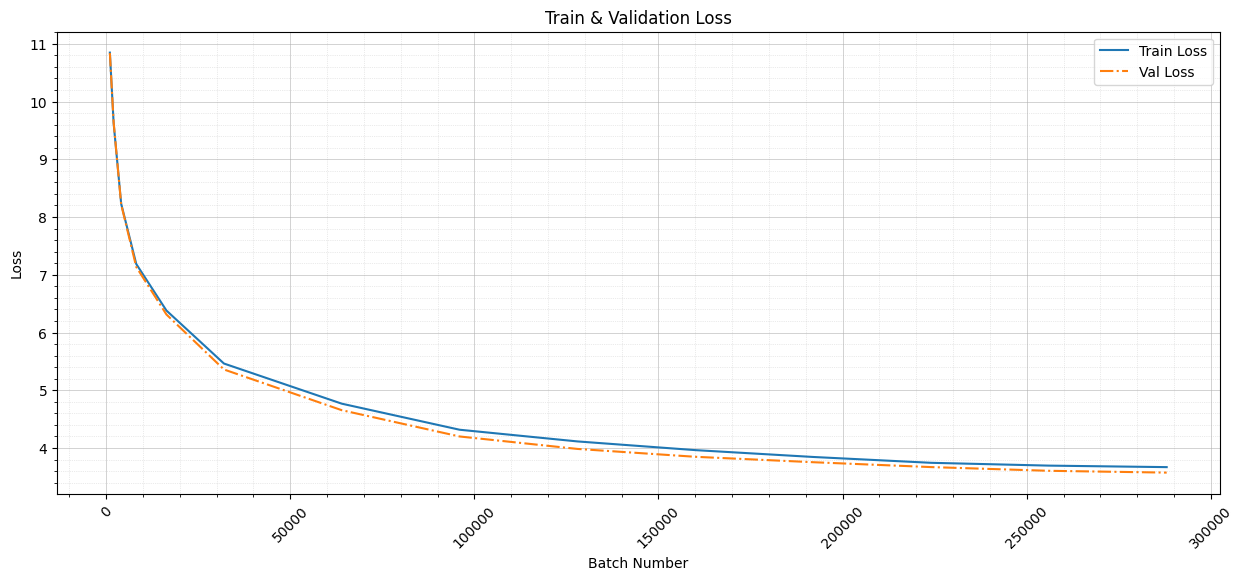

In [14]:
# -- Plot training and validation loss vs batch number ------------------------------------------------------
import matplotlib.pyplot as plt

def plot_train_val_loss(batches_seen, train_losses, val_losses):
    logger.info("Generating plot: training and validation loss vs batch number.")

    fig, ax1 = plt.subplots(figsize=(15,6))

    # Plot training and validation loss against epochs
    ax1.plot(batches_seen, train_losses, label="Train Loss")
    ax1.plot(batches_seen, val_losses, linestyle="-.", label="Val Loss")
    ax1.set_xlabel("Batch Number")
    #ax1.set_ylim(0)
    ax1.set_ylabel("Loss")
    ax1.set_title("Train & Validation Loss")
    ax1.legend(loc="upper right")
    # --- Add Subgrid (Minor Grid Lines) ---
    ax1.minorticks_on()  # Enable minor ticks
    # Major grid (main grid lines)
    ax1.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.8)
    # Minor grid (subgrid lines)
    ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
    ax1.grid(True)

    #fig.tight_layout()  # Adjust layout to make room
    plt.xticks(rotation=45)
    plt.savefig(f"loss-plot-{run_id}.pdf")
    plt.show()

plot_train_val_loss(batches_seen, train_losses, val_losses)


In [ ]:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.advanced_generation(input_tokens=input_tokens, max_new_tokens=40, temperature=1.3, top_k=20)

# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")

In [ ]:
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo

nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)
info = nvmlDeviceGetMemoryInfo(handle)

print(f"Used: {info.used // (1024 ** 2)} MB, Free: {info.free // (1024 ** 2)} MB, Total: {info.total // (1024 ** 2)} MB")

In [ ]:
# -- load model form checkpoint----------------------------------------------------

# 1) Re‑instantiate everything with the *same* hyperparameters
vocab_size = 50304
block_size = 1024
n_embd = 1024 # 768 1024 1280
n_head = 16 # 12 16 20
n_layer = 24 # 12 24 36
dropout = 0.1
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scaler = GradScaler(device, enabled=(device == 'cuda'))

# 2) Load tokenizer as before
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)

# 3) Point to your checkpoint
ckpt_path = r"outputs\output_v17\pre_training\run_1756251457\checkpoint_step_100000.pth"
assert os.path.isfile(ckpt_path), f"Checkpoint not found at {ckpt_path}"

# 4) Load the checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])

# # If you saved the scaler state dict, restore it
# if 'scaler_state_dict' in ckpt:
#     scaler.load_state_dict(ckpt['scaler_state_dict'])

# # When loading checkpoint:
# if 'warmup_scheduler_state_dict' in checkpoint:
#     warmup_scheduler.load_state_dict(checkpoint['warmup_scheduler_state_dict'])
# if 'plateau_scheduler_state_dict' in checkpoint:
#     scheduler.load_state_dict(checkpoint['plateau_scheduler_state_dict'])

# Load plot history
history = ckpt['history']
batches_seen = history['batches_seen']
train_losses = history['train_losses']
val_losses   = history['val_losses']

start_step = ckpt.get('epoch', None)
print(f"Loaded checkpoint from step {start_step}. Resuming from there.")

# 5) (Optional) Set model to eval or train
# For continued training:
model.train()
# For inference only:
# model.eval()

# 6) Example inference to verify it works:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.advanced_generation(input_tokens=input_tokens, max_new_tokens=50, temperature=1.7, top_k=10)

# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")